# Phase 4 — Property Value Regression (Supervised)

Trains Random Forest and XGBoost models to predict listing price, then saves predictions for the undervalued-detection step.

**Outputs**
- `data/processed/model_predictions.parquet`
- `outputs/figures/04_feature_importance_rf.png`
- `outputs/figures/04_feature_importance_xgb.png`
- `outputs/figures/04_predictions_xgb.png`
- `outputs/models/random_forest.joblib`
- `outputs/models/xgboost.joblib`

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from sklearn.model_selection import train_test_split

from src.utils import (
    MERGED_DATA, CLUSTER_LABELS, MODEL_PREDICTIONS, FIGURES_DIR, MODELS_DIR, ensure_dirs
)
from src.regression import (
    MODEL_FEATURES, TARGET,
    prepare_model_data, train_models, evaluate_models,
    plot_feature_importance, plot_predictions, save_models
)

ensure_dirs()

## 1. Load Data

In [3]:
df = pd.read_parquet(MERGED_DATA)
cluster_labels = pd.read_csv(CLUSTER_LABELS)
print(f'Merged rows: {len(df):,}  |  Cluster labels: {len(cluster_labels):,}')

Merged rows: 856,386  |  Cluster labels: 21,529


## 2. Prepare Feature Matrix

Joins cluster labels onto the merged data. Drops rows with any missing model feature.

In [4]:
df_model, X, y = prepare_model_data(df, cluster_labels)
print(f'Model dataset: {len(X):,} rows')
print(f'Features: {list(X.columns)}')
X.describe().round(2)

Model dataset: 702,438 rows
Features: ['bed', 'bath', 'house_size', 'acre_lot', 'bed_bath_ratio', 'total_rooms', 'zhvi_current', 'growth_1yr', 'growth_5yr', 'cluster']


,bed,bath,house_size,acre_lot,bed_bath_ratio,total_rooms,zhvi_current,growth_1yr,growth_5yr,cluster
count,702438.00,702438.0,702438.00,702438.00,702438.00,702438.00,702438.00,702438.00,702438.00,702438.00
mean,3.42,2.6,2169.23,12.51,1.48,6.01,426789.23,0.00,0.29,0.62
std,1.10,1.2,1213.63,787.09,0.59,2.09,324865.57,0.04,0.14,0.88
min,1.00,1.0,101.00,0.00,0.08,2.00,28552.41,-0.42,-0.60,0.00
25%,3.00,2.0,1402.00,0.14,1.00,5.00,252666.95,-0.02,0.21,0.00
50%,3.00,2.0,1877.00,0.23,1.50,6.00,350610.82,0.00,0.30,0.00
75%,4.00,3.0,2587.00,0.51,1.50,7.00,497602.66,0.03,0.37,1.00
max,15.00,15.0,19915.00,100000.00,14.00,30.00,8078218.89,0.35,1.12,3.00


## 3. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 561,950  |  Test: 140,488


## 4. Train Models

Random Forest is capped at 500 k training rows to keep runtime manageable. XGBoost trains on the full set with early-stop evaluation.

In [6]:
models = train_models(X_train, y_train)

Training Random Forest…
Training XGBoost…


## 5. Evaluate

In [7]:
results = evaluate_models(models, X_test, y_test)


Model                             MAE        R²
------------------------------------------------
Random Forest          $      148,337    0.7555
XGBoost                $      149,680    0.7618


## 6. Feature Importance

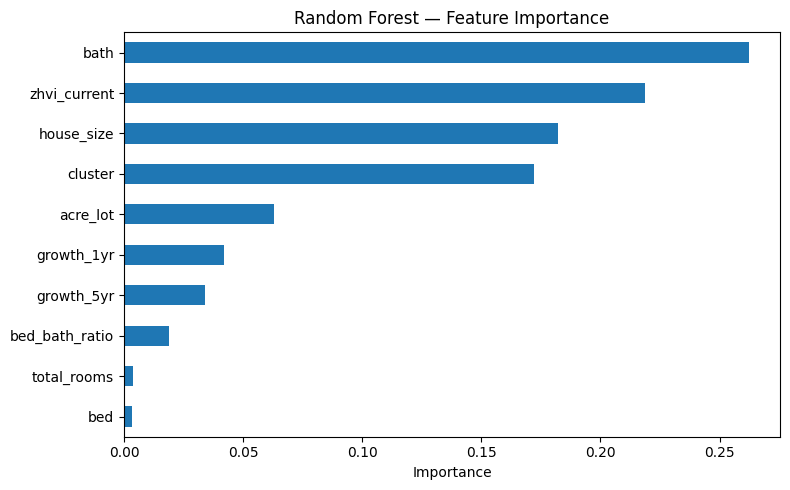

Saved → outputs/figures/04_feature_importance_rf.png


In [8]:
plot_feature_importance(
    results['Random Forest']['model'], MODEL_FEATURES,
    title='Random Forest — Feature Importance',
    save_path=FIGURES_DIR / '04_feature_importance_rf.png'
)
print('Saved → outputs/figures/04_feature_importance_rf.png')

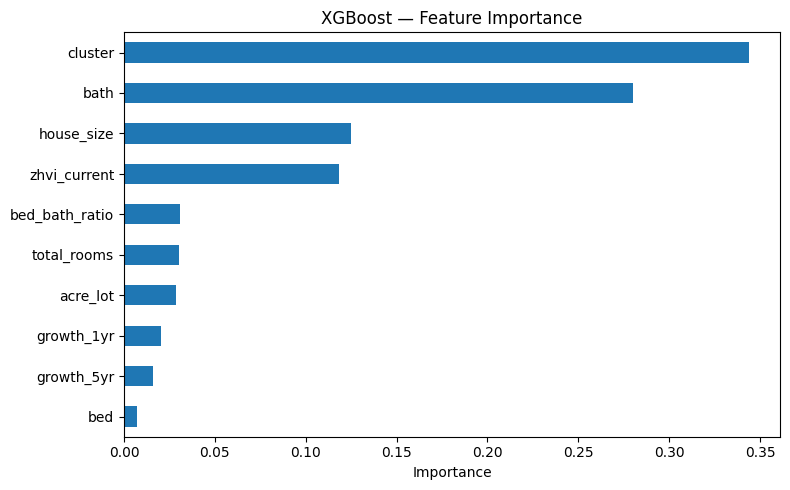

Saved → outputs/figures/04_feature_importance_xgb.png


In [9]:
plot_feature_importance(
    results['XGBoost']['model'], MODEL_FEATURES,
    title='XGBoost — Feature Importance',
    save_path=FIGURES_DIR / '04_feature_importance_xgb.png'
)
print('Saved → outputs/figures/04_feature_importance_xgb.png')

## 7. Predicted vs Actual (XGBoost)

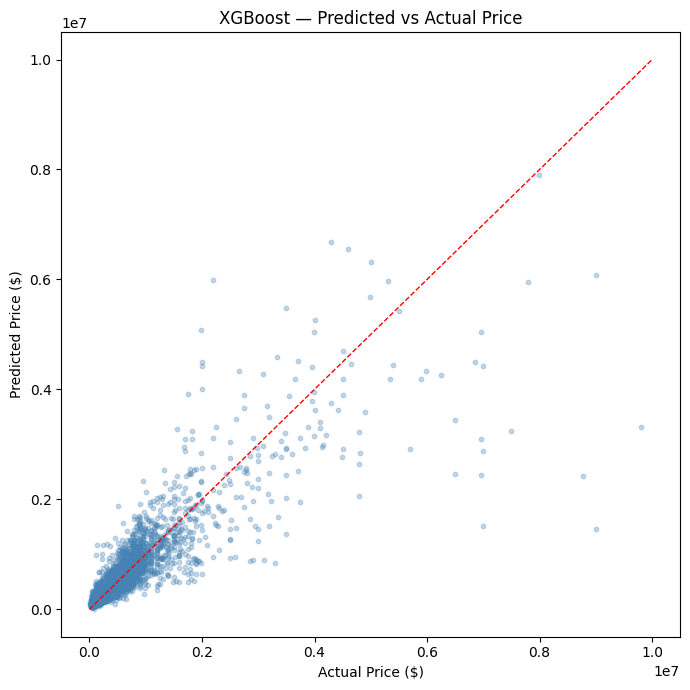

Saved → outputs/figures/04_predictions_xgb.png


In [10]:
plot_predictions(
    y_test, results['XGBoost']['preds'],
    title='XGBoost — Predicted vs Actual Price',
    save_path=FIGURES_DIR / '04_predictions_xgb.png'
)
print('Saved → outputs/figures/04_predictions_xgb.png')

## 8. Save Predictions & Models

In [11]:
best_model = results['XGBoost']['model']
df_model = df_model.copy()
df_model['predicted_price'] = best_model.predict(X)

df_model.to_parquet(MODEL_PREDICTIONS, index=False)
print(f'Saved predictions → {MODEL_PREDICTIONS}')

Saved predictions → /Users/zacharypeng/projects/csen140proj/notebooks/../data/processed/model_predictions.parquet


In [12]:
save_models(results, MODELS_DIR)

Saved → /Users/zacharypeng/projects/csen140proj/notebooks/../outputs/models/random_forest.joblib
Saved → /Users/zacharypeng/projects/csen140proj/notebooks/../outputs/models/xgboost.joblib
